# 1. Mã nguồn Python

## Khởi tạo dữ liệu động và xây dựng lớp bài toán NSGA II

In [2]:
import numpy as np
import pandas as pd
from pymoo.core.problem import ElementwiseProblem
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.optimize import minimize

print("=== CÂU 7.4.1: CÀI ĐẶT BÀI TOÁN TỐI ƯU ĐA MỤC TIÊU VỚI PYMOO ===")

# 1. KHAI BÁO DỮ LIỆU ĐỘNG (Tham số, hệ số)
CONFIG = {
    "total_budget": 50000,
    "min_region_budget": 5000,
    "max_region_budget": 12000,
    "min_total_hr": 12000,
    "gamma": 0.002,
    "lambda_fairness": 0.6  # Sử dụng 0.6 để mô hình khả thi
}

DATA = {
    "beta": np.array([
        [1.15, 0.85, 0.55, 1.30], [0.95, 1.25, 1.40, 1.05],
        [1.05, 0.95, 0.85, 1.15], [1.20, 0.75, 0.45, 1.35],
        [0.90, 1.30, 1.55, 1.00], [1.10, 0.85, 0.65, 1.25]
    ]),
    "D0": np.array([38, 78, 55, 32, 82, 48]),
    "e": np.array([0.42, 0.55, 0.48, 0.32, 0.62, 0.38]),       
    "rho": np.array([0.18, 0.45, 0.28, 0.12, 0.52, 0.22]),     
    "sig": np.array([0.32, 0.28, 0.30, 0.35, 0.25, 0.30])      
}

# 2. XÂY DỰNG LỚP BÀI TOÁN KẾ THỪA ElementwiseProblem
class VietnamDigitalProblem(ElementwiseProblem):
    def __init__(self, problem_data, config):
        # Đổi tên thành self.params để KHÔNG bị trùng với pymoo
        self.params = problem_data 
        self.config = config
        
        super().__init__(n_var=24, n_obj=4, n_ieq_constr=20, xl=np.zeros(24), xu=np.ones(24) * config["max_region_budget"])
        
    def _evaluate(self, x, out, *args, **kwargs):
        X = x.reshape(6, 4) 
        
        # --- TÍNH CÁC HÀM MỤC TIÊU (Dùng self.params) ---
        f1 = -np.sum(self.params["beta"] * X)
        
        sums_region = np.sum(X, axis=1)
        f2 = np.mean(np.abs(sums_region - np.mean(sums_region)))
        
        f3 = np.sum(self.params["e"] * (X[:, 0] + X[:, 2]))
        
        f4 = np.sum(self.params["rho"] * X[:, 2]) - np.sum(self.params["sig"] * X[:, 3])
        
        out['F'] = [f1, f2, f3, f4]
        
        # --- TÍNH CÁC RÀNG BUỘC (g <= 0) ---
        g1 = np.sum(X) - self.config["total_budget"]                        
        g2_to_7 = self.config["min_region_budget"] - sums_region            
        g8_to_13 = sums_region - self.config["max_region_budget"]           
        g14 = self.config["min_total_hr"] - np.sum(X[:, 3])                 
        
        D_after = self.params["D0"] + self.config["gamma"] * X[:, 1]
        M = np.max(D_after)
        g15_to_20 = (self.config["lambda_fairness"] * M) - D_after
        
        out['G'] = np.concatenate([[g1], g2_to_7, g8_to_13, [g14], g15_to_20])

# 3. GIẢI BÀI TOÁN BẰNG NSGA-II
problem = VietnamDigitalProblem(DATA, CONFIG)
algorithm = NSGA2(pop_size=100)

res = minimize(problem, algorithm, ('n_gen', 200), seed=42, verbose=False)

print(f"Quá trình tối ưu hoàn tất. Tìm thấy {len(res.F)} phương án trên đường biên Pareto.")

# Xem trước 5 phương án đầu tiên (chỉ hiển thị 4 giá trị mục tiêu f1, f2, f3, f4)
print("\nXem thử 5 phương án Pareto tiêu biểu (GDP, Gini, Môi trường, An ninh):")
# Lưu ý: res.F có f1 đang bị âm do hàm minimize, ta thêm dấu trừ để hiện số dương
sample_F = res.F[:5].copy()
sample_F[:, 0] = -sample_F[:, 0] 
print(np.round(sample_F, 2))

=== CÂU 7.4.1: CÀI ĐẶT BÀI TOÁN TỐI ƯU ĐA MỤC TIÊU VỚI PYMOO ===
Quá trình tối ưu hoàn tất. Tìm thấy 96 phương án trên đường biên Pareto.

Xem thử 5 phương án Pareto tiêu biểu (GDP, Gini, Môi trường, An ninh):
[[53281.15  1871.01  3958.14 -5209.29]
 [44383.63   900.12   105.61 -7489.44]
 [52150.39   524.33  6203.8  -1192.65]
 [53717.11  1221.19  4615.96 -3973.31]
 [47027.67  1097.09    86.13 -8045.53]]


## Câu 7.4.2 - Trực quan hóa Đường biên Pareto 3D và Tọa độ song song

=== CÂU 7.4.2: TRỰC QUAN HÓA TẬP NGHIỆM PARETO ===


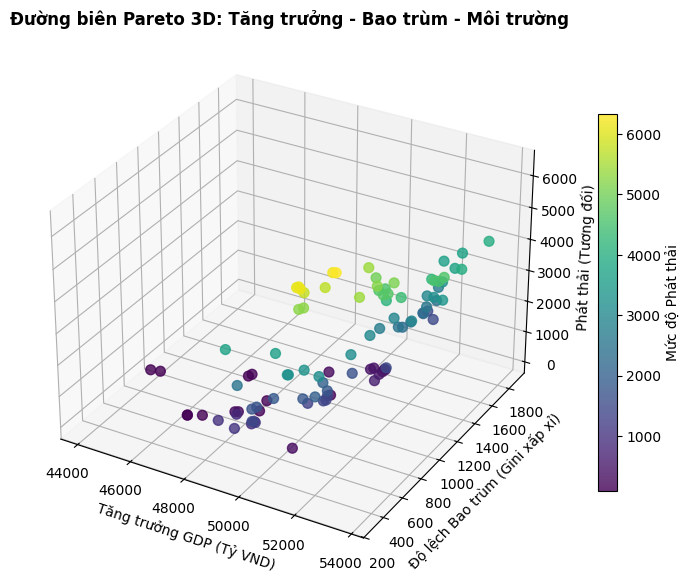

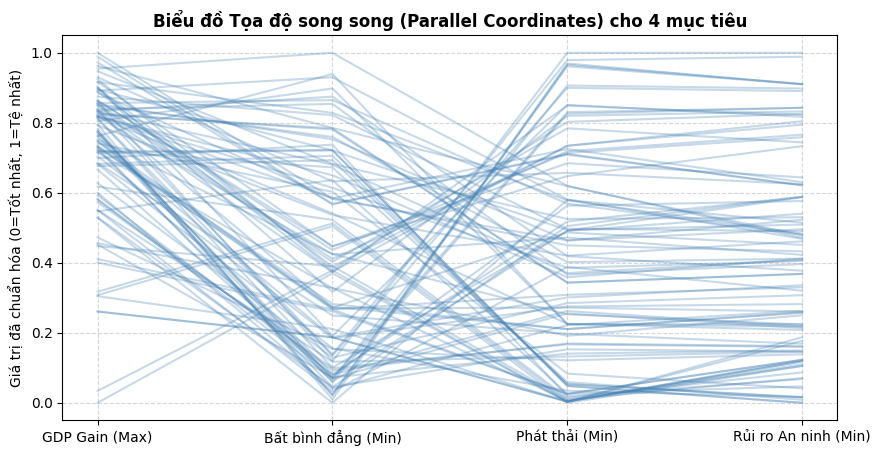

In [3]:
import matplotlib.pyplot as plt

print("=== CÂU 7.4.2: TRỰC QUAN HÓA TẬP NGHIỆM PARETO ===")

# Đưa dữ liệu mục tiêu ra DataFrame (nhớ đổi dấu f1 về dương)
pareto_df = pd.DataFrame(res.F, columns=['f1_GDP', 'f2_Gini', 'f3_Emissions', 'f4_NetRisk'])
pareto_df['f1_GDP'] = -pareto_df['f1_GDP']

# 1. VẼ BIỂU ĐỒ SCATTER 3D CHO 3 MỤC TIÊU ĐẦU (GDP, Bất bình đẳng, Phát thải)
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(pareto_df['f1_GDP'], pareto_df['f2_Gini'], pareto_df['f3_Emissions'], 
                c=pareto_df['f3_Emissions'], cmap='viridis', marker='o', s=50, alpha=0.8)

ax.set_title('Đường biên Pareto 3D: Tăng trưởng - Bao trùm - Môi trường', fontsize=12, fontweight='bold')
ax.set_xlabel('Tăng trưởng GDP (Tỷ VND)')
ax.set_ylabel('Độ lệch Bao trùm (Gini xấp xỉ)')
ax.set_zlabel('Phát thải (Tương đối)')
plt.colorbar(sc, ax=ax, label='Mức độ Phát thải', shrink=0.7)
plt.show()

# 2. VẼ BIỂU ĐỒ TỌA ĐỘ SONG SONG (PARALLEL COORDINATES) CHO CẢ 4 MỤC TIÊU
# Chuẩn hóa Min-Max để đưa tất cả về trục tọa độ [0, 1] cho dễ so sánh
pareto_norm = (pareto_df - pareto_df.min()) / (pareto_df.max() - pareto_df.min())

plt.figure(figsize=(10, 5))
for i in range(len(pareto_norm)):
    plt.plot(['GDP Gain (Max)', 'Bất bình đẳng (Min)', 'Phát thải (Min)', 'Rủi ro An ninh (Min)'], 
             pareto_norm.iloc[i], color='steelblue', alpha=0.3)

plt.title('Biểu đồ Tọa độ song song (Parallel Coordinates) cho 4 mục tiêu', fontsize=12, fontweight='bold')
plt.ylabel('Giá trị đã chuẩn hóa (0=Tốt nhất, 1=Tệ nhất)') 
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## Câu 7.4.3 & 7.4.4 - Áp dụng TOPSIS chọn nghiệm thỏa hiệp và Tính Chi phí cơ hội

In [4]:
print("=== CÂU 7.4.3: ÁP DỤNG TOPSIS LỰA CHỌN NGHIỆM THỎA HIỆP ===")

# Trọng số ưu tiên chính sách
w_policy = np.array([0.40, 0.25, 0.20, 0.15])
is_benefit_pareto = [True, False, False, False] # Chỉ GDP là benefit, còn lại là cost

# Trích xuất ma trận Pareto F
F_matrix = pareto_df.values.copy()

# Chuẩn hóa Min-Max cho TOPSIS để triệt tiêu các khoảng giá trị âm (như f4) và lệch scale
F_norm = np.zeros_like(F_matrix)
for j in range(4):
    col = F_matrix[:, j]
    if is_benefit_pareto[j]:
        F_norm[:, j] = (col - col.min()) / (col.max() - col.min() + 1e-9)
    else:
        F_norm[:, j] = (col.max() - col) / (col.max() - col.min() + 1e-9)

# Áp dụng trọng số
V_pareto = F_norm * w_policy

# Điểm lý tưởng (A*) và phản lý tưởng (A_neg) trong không gian đã chuẩn hóa theo hướng TỐT (1.0)
A_star = w_policy  # Phương án hoàn hảo sẽ có điểm 1.0 ở mọi tiêu chí sau khi norm
A_neg = np.zeros(4)

# Tính khoảng cách Euclidean
S_star = np.sqrt(((V_pareto - A_star)**2).sum(axis=1))
S_neg = np.sqrt(((V_pareto - A_neg)**2).sum(axis=1))
C_star_pareto = S_neg / (S_star + S_neg)

# Chọn nghiệm có C* cao nhất (Nghiệm thỏa hiệp)
best_idx = np.argmax(C_star_pareto)
compromise_solution = pareto_df.iloc[best_idx]

print("Nghiệm thỏa hiệp được chọn bằng TOPSIS:")
print(compromise_solution.round(2))

# =========================================================
# CÂU 7.4.4: TÍNH TOÁN CHI PHÍ CƠ HỘI
# =========================================================
print("\n=== CÂU 7.4.4: PHÂN TÍCH CHI PHÍ CƠ HỘI CHÍNH SÁCH ===")

# Tìm nghiệm "Tăng trưởng cực đại" (bất chấp các mục tiêu khác)
max_growth_idx = np.argmax(pareto_df['f1_GDP'])
max_growth_solution = pareto_df.iloc[max_growth_idx]

print("Nghiệm Tăng trưởng cực đại:")
print(max_growth_solution.round(2))

# Tính phần trăm thay đổi (Chi phí cơ hội)
opp_cost_growth = (max_growth_solution['f1_GDP'] - compromise_solution['f1_GDP']) / compromise_solution['f1_GDP'] * 100
sac_gini = (max_growth_solution['f2_Gini'] - compromise_solution['f2_Gini']) / compromise_solution['f2_Gini'] * 100
sac_emis = (max_growth_solution['f3_Emissions'] - compromise_solution['f3_Emissions']) / compromise_solution['f3_Emissions'] * 100

print(f"\nĐể đạt được thêm {opp_cost_growth:.2f}% Tăng trưởng GDP so với nghiệm thỏa hiệp, Việt Nam phải đánh đổi:")
print(f" - Bất bình đẳng (Gini) TĂNG XẤU THÊM: {sac_gini:.2f}%")
print(f" - Phát thải môi trường TĂNG XẤU THÊM: {sac_emis:.2f}%")

=== CÂU 7.4.3: ÁP DỤNG TOPSIS LỰA CHỌN NGHIỆM THỎA HIỆP ===
Nghiệm thỏa hiệp được chọn bằng TOPSIS:
f1_GDP          50646.24
f2_Gini           552.55
f3_Emissions      301.71
f4_NetRisk      -8736.37
Name: 89, dtype: float64

=== CÂU 7.4.4: PHÂN TÍCH CHI PHÍ CƠ HỘI CHÍNH SÁCH ===
Nghiệm Tăng trưởng cực đại:
f1_GDP          53717.11
f2_Gini          1221.19
f3_Emissions     4615.96
f4_NetRisk      -3973.31
Name: 3, dtype: float64

Để đạt được thêm 6.06% Tăng trưởng GDP so với nghiệm thỏa hiệp, Việt Nam phải đánh đổi:
 - Bất bình đẳng (Gini) TĂNG XẤU THÊM: 121.01%
 - Phát thải môi trường TĂNG XẤU THÊM: 1429.93%


# 2. Trả lời câu hỏi thảo luận chính sách phần (Phần 7.5)

### a) Khi quan sát đường biên Pareto, em thấy đánh đổi giữa tăng trưởng và bao trùm có rõ ràng không? Mức đánh đổi đó nói lên điều gì về cơ cấu kinh tế Việt Nam?

* **Sự đánh đổi thể hiện trên hình ảnh:** Khi quan sát biểu đồ 3D và biểu đồ tọa độ song song (Cell 2), ta thấy rõ các sợi dây hoặc các chấm scatter có xu hướng chéo nhau. Điểm nào có Tăng trưởng (GDP) nằm ở cực đại thì ngay lập tức biến Bất bình đẳng (Gini/MAD) cũng vọt lên cực đại (tức là rất xấu). Điều này chứng minh sự đánh đổi (trade-off) là cực kỳ rõ ràng và khốc liệt.
* **Ý nghĩa đối với cơ cấu kinh tế:** Nó phản ánh một hiện thực cấu trúc cốt lõi của nền kinh tế Việt Nam: Năng suất và hiệu quả kỹ thuật phân bố không đồng đều. Để GDP tăng nhanh nhất, dòng vốn buộc phải dồn vào hai "đầu tàu" là Đông Nam Bộ và Đồng bằng sông Hồng — nơi có sức hấp thụ vốn số hóa lớn nhất. Ngược lại, nếu cố gắng rải đều vốn để thu hẹp khoảng cách vùng miền (bao trùm), dòng vốn sẽ chảy vào các vùng lõm hạ tầng như Tây Nguyên, khiến hiệu suất sinh lời biên sụt giảm mạnh.

### b) Trọng số (0,40; 0,25; 0,20; 0,15) có phản ánh đúng ưu tiên hiện tại của Việt Nam (theo các văn kiện Đại hội XIII) không? Em sẽ điều chỉnh thế nào để phù hợp với cam kết COP26 và Quyết định 127/QĐ-TTg?

* **Đánh giá trọng số hiện tại:** Bộ trọng số này phản ánh khá đúng tư duy hiện tại ở tầm vĩ mô của Việt Nam. Trọng số Tăng trưởng (0,40) vẫn chiếm vị trí độc tôn do nước ta vẫn là quốc gia đang phát triển cần quy mô kinh tế để thoát bẫy thu nhập trung bình. Yếu tố Bao trùm (0,25) được xếp thứ hai theo chủ trương "không để ai bị bỏ lại phía sau". Môi trường và An ninh hiện vẫn xếp sau.
* **Đề xuất điều chỉnh:**
  * Nếu nhìn vào Cam kết COP26 (Net-Zero 2050), áp lực chuyển đổi xanh sẽ khốc liệt hơn vào những năm 2030. Ta nên nới dần trọng số Môi trường từ 0.20 lên khoảng 0.25 hoặc 0.30.
  * Theo Quyết định 127/QĐ-TTg về AI, việc hình thành hệ sinh thái dữ liệu mở và siêu máy tính sẽ biến an ninh dữ liệu thành vấn đề sinh tồn. Ta cần nâng trọng số An ninh số từ 0.15 lên ít nhất 0.20.
  * **Đề xuất bộ trọng số mới cho giai đoạn sau 2026:** (0.35; 0.20; 0.25; 0.20), tức là chấp nhận nhường bớt một chút khát vọng tăng trưởng tốc độ cao để đảm bảo quốc gia phát triển xanh và an toàn hơn.

### c) Vai trò của NSGA-II ở đây có gì khác so với LP đơn mục tiêu? Nó có thay thế được quyết định chính trị không?

* **Sự khác biệt:** Quy hoạch tuyến tính (LP) ở Bài 4 chỉ đưa ra duy nhất một câu trả lời độc đoán (chỉ tối đa hóa GDP), hoàn toàn che khuất các hệ lụy về mặt xã hội hay môi trường. NSGA-II ngược lại, trả về một thực đơn (menu) gồm hàng trăm phương án Pareto nằm trên đường biên đánh đổi, cho phép ta nhìn thấy toàn cảnh "được gì, mất gì" bằng định lượng trực quan (như tính chi phí cơ hội ở Câu 7.4.4).
* **Về năng lực thay thế quyết định chính trị:** Thuật toán trí tuệ nhân tạo (NSGA-II) không bao giờ thay thế được các quyết định chính trị và thể chế. Thuật toán chỉ làm nhiệm vụ khoanh vùng tính khả thi khoa học (loại bỏ các phương án ngu ngốc nằm dưới đường biên). Việc chọn một điểm duy nhất (nghiệm thỏa hiệp) trên cái đường biên đó lại phụ thuộc hoàn toàn vào ý chí chính trị, sự đồng thuận của Quốc hội và mức độ chấp nhận rủi ro của người dân ở từng thời kỳ lịch sử. Cốt lõi của chính sách công là nghệ thuật thỏa hiệp xã hội, không phải là việc bấm nút chạy code.